In [3]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [4]:
class AgentState(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    random_number: int

In [57]:
def setup_game(state: AgentState) -> AgentState:
    """This function initializes the game state with a random number to guess and resets the attempts."""
    print(f"Welcome {state['player_name']}! Let's start the game.")
    state['random_number'] = random.randint(state['lower_bound'], state['upper_bound'])
    state['attempts'] = 0
    state['guesses'] = []
    print(f"I have selected a random number between {state['lower_bound']} and {state['upper_bound']}. Try to guess it!")
    print(f"You have a maximum of 7 attempts to guess the number.")
    print(f"Random number for debugging: {state['random_number']}")  # For debugging purposes, remove in production
    print(f'original bounds -> [{state['lower_bound']} : {state['upper_bound']}]\n')
    
    return state

def guess_number(state:AgentState) -> AgentState:
    """This function processes a player's guess"""
    state['guesses'].append(random.randint(state['lower_bound'], state['upper_bound']))  # Simulating a guess for demonstration
    state['attempts'] += 1
    return state

def hint_node(state:AgentState) -> AgentState:
    """This function provides a hint based on the last guess."""
    
    if state['attempts'] <= 7:
        last_guess = state['guesses'][-1]
        if last_guess < state['random_number']:
            state['lower_bound'] = last_guess + 1
            print(f"[{state['attempts']}] Hint: Your guess of {last_guess} is too low.")
            print(f'new bounds -> [{state['lower_bound']} : {state['upper_bound']}]')
        elif last_guess > state['random_number']:
            state['upper_bound'] = last_guess - 1
            print(f"[{state['attempts']}] Hint: Your guess of {last_guess} is too high.")
            print(f'new bounds -> [{state['lower_bound']} : {state['upper_bound']}]')
        else:
            print(f"[{state['attempts']}] Congratulations! You've guessed the number {state['random_number']} in {state['attempts']} attempts.")
            print(f'new bounds -> [{state['lower_bound']} : {state['upper_bound']}]')

    
    return state

def should_continue(state:AgentState) -> AgentState:
    """This function checks if the player has remaining attempts."""
    if state['guesses'][-1] == state['random_number']:
        return "end"
    elif state['attempts'] >= 7:
        print(f"Game Over! You've used all your attempts. The number was {state['random_number']}.")
        return "end"
    else:
        return "continue"


In [58]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_game)
graph.add_node("guess", guess_number)
graph.add_node("hint_node", hint_node)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint_node")
graph.add_conditional_edges(
    "hint_node",
    should_continue,
    {
        "continue": "guess",
        "end": END
    }
)

app = graph.compile()

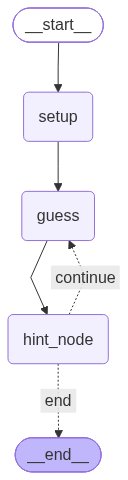

In [50]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))  # display the graph as an image in the notebook

In [65]:
input = AgentState(player_name="Matty", guesses=[], attempts=0, lower_bound=0, upper_bound=100)  # create an initial state for the graph
ans = app.invoke(input)  # invoke the graph with the initial state

Welcome Matty! Let's start the game.
I have selected a random number between 0 and 100. Try to guess it!
You have a maximum of 7 attempts to guess the number.
Random number for debugging: 13
original bounds -> [0 : 100]

[1] Hint: Your guess of 94 is too high.
new bounds -> [0 : 93]
[2] Hint: Your guess of 1 is too low.
new bounds -> [2 : 93]
[3] Hint: Your guess of 29 is too high.
new bounds -> [2 : 28]
[4] Hint: Your guess of 17 is too high.
new bounds -> [2 : 16]
[5] Hint: Your guess of 4 is too low.
new bounds -> [5 : 16]
[6] Hint: Your guess of 15 is too high.
new bounds -> [5 : 14]
[7] Hint: Your guess of 9 is too low.
new bounds -> [10 : 14]
Game Over! You've used all your attempts. The number was 13.


In [66]:
ans

{'player_name': 'Matty',
 'guesses': [94, 1, 29, 17, 4, 15, 9],
 'attempts': 7,
 'lower_bound': 10,
 'upper_bound': 14,
 'random_number': 13}